In [1]:
import matplotlib.pyplot as plt
import qsvm4eo
import numpy as np
import pandas as pd 

# Chain embedding

In this notebook we explore the structure of the Chain Embedding. 

In this embedding each datapoint $b_i = (b_i^1, b_i^2, \cdots, b_i^k)$ is mapped to a graph whose node coordinates are: 

$v_i^j = (-c_1 + c_2\cdot j, b_i^j)$, 

Where $b_i^j$ are the features of the point $i$, and $c_1$ and $c_2$ are constants chosen so that the embeddability criterium for the device is satisfied. This means that $|c_1|\leq 38$ and $|c_1 - 3c_2| \leq 38$.


In [2]:
df_train = pd.read_csv("./../../data/train_32.csv")
df_test = pd.read_csv("./../../data/test_32.csv")
embedding_train = qsvm4eo.ChainEmbedding(
    df_train
)
embedding_test = qsvm4eo.ChainEmbedding(
    df_test
)

In [3]:
qbits_train = embedding_train.embed()
qbits_test = embedding_test.embed()

We check if the graphs are embeddable

In [4]:
print(qsvm4eo.utils.check_embeddability(qbits_train))
print(qsvm4eo.utils.check_embeddability(qbits_test))

{}
{}


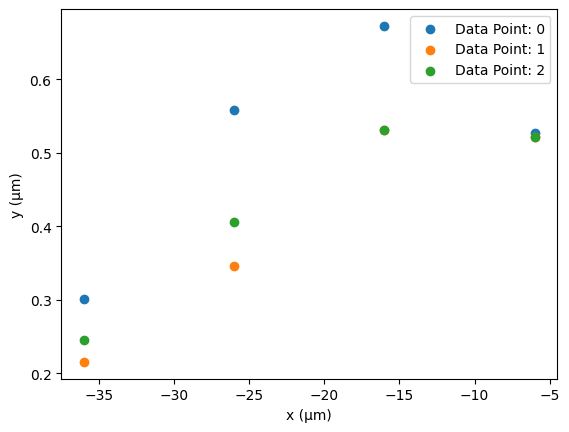

In [5]:
# Let's graph the first 3 qubit geometries.
for c, qb in enumerate(qbits_train[:3]):
    plt.scatter(qb[:, 0], qb[:, 1], label="Data Point: %i" % c)

plt.xlabel("x (µm)")
plt.ylabel("y (µm)")

plt.legend()
plt.show()